# 📊 EDA: Análisis de Influencia de YouTube en el Consumo

## 🎯 Objeto de Estudio
El propósito de este análisis es determinar cómo las **búsquedas y reproducciones en YouTube** impactan directamente en el consumo de productos relacionados.

---

## 🔍 Metodología y Recogida de Datos
Para este estudio, se cruzarán datos de dos fuentes clave de la infraestructura de Google para medir el interés de los usuarios:

1.  **Google Trends:** Para obtener datos sobre las **búsquedas intencionadas** y tendencias globales.
    "./searched_with_top-queries_ES_20210322-2141_20260322-2141.csv"
2.  **API de YouTube:** A través de *Google Cloud Platform*, para extraer métricas de contenido y visualizaciones.

> ### 🪵 Enfoque del Análisis
> Para aportar mayor profundidad, el estudio se focalizará específicamente en el sector del **bricolaje y la carpintería**.

---

## 🛠️ Requisitos Técnicos
Para interactuar con la API de Google desde el entorno de desarrollo, es necesario instalar el cliente oficial de Python:

```bash
pip install google-api-python-client

In [61]:
%pip install --upgrade google-api-python-client

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



## 🔑 Registro y Conexión

Para habilitar el acceso a los datos de la plataforma de Google, es necesario seguir un proceso de configuración en la consola de desarrolladores:

1.  **Registro y Proyecto:** Crear un nuevo proyecto en [Google Cloud Console](https://console.cloud.google.com).
2.  **Habilitar Servicios:** Añadir los servicios específicos que se van a consumir (en este caso, **YouTube Data API v3**).
3.  **Credenciales:** Generar una **API Key** exclusiva para el proyecto, la cual debe almacenarse de forma segura.

### 💻 Configuración del Acceso
Una vez obtenida la clave, la almacenamos en una constante y configuramos el objeto de servicio para realizar las peticiones:

```python
from googleapiclient.discovery import build

# Definición de credenciales y servicio
API_KEY = "TU_API_KEY_AQUI"


# Creación de la instancia de conexión
youtube = build(YOUTUBE_SERVICE_NAME, YOUTUBE_API_VERSION, developerKey=API_KEY)

In [62]:
#para cargar variables de entorno desde un archivo .env
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
from googleapiclient.discovery import build
import pandas as pd
import os
from dotenv import load_dotenv

# Cargar las variables de entorno desde el archivo .env
load_dotenv()

# Sustituye con tu clave de API obtenida en Google Cloud Console
API_KEY = os.getenv("API_KEY")
YOUTUBE_SERVICE_NAME = "youtube"
YOUTUBE_API_VERSION = "v3"
youtube = build(YOUTUBE_SERVICE_NAME, YOUTUBE_API_VERSION, developerKey=API_KEY)

PERFILES = {
    'carpinteria': {'edad_media': 40, 'sexo_h': 0.92, 'sexo_m': 0.08},
    'bricolaje': {'edad_media': 30, 'sexo_h': 0.54, 'sexo_m': 0.46}
}

In [64]:
#definimos la función para buscar videos en YouTube de ejemplo sobre carpintería o bricolaje
def buscar_videos_youtube(query, max_results=10):
    # 1. Búsqueda inicial para obtener IDs de videos
    search_request = youtube.search().list(
        q=query,
        part='snippet',
        type='video',
        maxResults=max_results,
        order='viewCount'
    )
    search_response = search_request.execute()
    
    video_ids = [item['id']['videoId'] for item in search_response['items']]
    
    # 2. Consulta detallada de estadísticas de esos IDs
    stats_request = youtube.videos().list(
        part='snippet,statistics',
        id=','.join(video_ids)
    )
    stats_response = stats_request.execute()
    
    
    # 3. Procesamiento de los datos para la tabla
    datos = []
    for video in stats_response['items']:
        datos.append({
            'Título': video['snippet']['title'],
            'Canal': video['snippet'],
            'Vistas': int(video['statistics'].get('viewCount', 0)),
            'Likes': int(video['statistics'].get('likeCount', 0)),
            'Publicado': video['snippet']['publishedAt'],
            'Link': f"https://www.youtube.com/watch?v={video['id']}"
        })
    
    return pd.DataFrame(datos)

In [65]:
buscar_videos_youtube("carpintería madera", max_results=5)

,Título,Canal,Vistas,Likes,Publicado,Link
0,Que pasaría si tocaras una sierra de madera? 🤔,"{'publishedAt': '2023-10-23T02:59:07Z', 'chann...",55128979,2472087,2023-10-23T02:59:07Z,https://www.youtube.com/watch?v=1qAYcGE4sxw
1,Talla de Cucharas en Madera | Un curso de Andr...,"{'publishedAt': '2020-07-06T08:00:04Z', 'chann...",27528885,952,2020-07-06T08:00:04Z,https://www.youtube.com/watch?v=LvJcDPOQ7Ms
2,Impresionante idea para usar martillo en la ca...,"{'publishedAt': '2025-09-02T20:37:33Z', 'chann...",24952192,188575,2025-09-02T20:37:33Z,https://www.youtube.com/watch?v=niTUI5D_X8c
3,1 Month in 10 Minutes! This Skillful Man Build...,"{'publishedAt': '2021-11-17T15:25:18Z', 'chann...",12585734,167573,2021-11-17T15:25:18Z,https://www.youtube.com/watch?v=mHIe9VSikbA
4,Sin clavos ni tornillos: El secreto de la carp...,"{'publishedAt': '2024-12-14T19:07:29Z', 'chann...",12102001,666169,2024-12-14T19:07:29Z,https://www.youtube.com/watch?v=P09aUgb0kyA


## 📂 Listado de Categorías y Limitaciones

En esta fase, procedemos a listar las categorías principales que ofrece la API de YouTube para clasificar el contenido. Es aquí donde identificamos el **primer obstáculo técnico** del análisis:

### ⚠️ El Problema de la Segmentación
YouTube utiliza un sistema de categorías predefinido (*Video Categories*) que presenta las siguientes limitaciones:

*   **Alcance Genérico:** Solo existen aproximadamente **30 categorías principales**.
*   **Falta de Especificidad:** Estas áreas son muy generales (ej. *Entertainment*, *Howto & Style*, *Education*).
*   **Sectorización Limitada:** No existe una categoría nativa específica para **"Bricolaje"** o **"Carpintería"**, lo que obliga a replantear la estrategia de búsqueda mediante *keywords* o etiquetas en lugar de ID de categoría.

> [!IMPORTANT]
> Debido a esta restricción, la segmentación del estudio deberá apoyarse en el filtrado por **términos de búsqueda (queries)** y no solo en los metadatos de categoría de la API.

In [66]:
def listar_categorias_por_region(region='ES'):
    # Llamada al endpoint videoCategories
    request = youtube.videoCategories().list(
        part='snippet',
        regionCode=region
    )
    response = request.execute()
    
    # Procesar los resultados en una lista de diccionarios
    categorias_lista = []
    for item in response.get('items',):
        categorias_lista.append({
            'ID_Categoria': item['id'],
            'Nombre': item['snippet']['title'],
            'Asignable': item['snippet']['assignable'] # Indica si es usable para nuevos videos
        })
    
    return pd.DataFrame(categorias_lista)

# Ejemplo: Listar categorías disponibles en España
df_categorias = listar_categorias_por_region('UK')
df_categorias

,ID_Categoria,Nombre,Asignable
0,1,Film & Animation,True
1,2,Autos & Vehicles,True
2,10,Music,True
3,15,Pets & Animals,True
4,17,Sports,True
5,18,Short Movies,False
6,19,Travel & Events,True
7,20,Gaming,True
8,21,Videoblogging,False
9,22,People & Blogs,True


In [67]:
def generar_dataset_herramientas(termino, max_vids=50):
    # Búsqueda restringida: solo videos, categoría Howto y Style (26)
    search_response = youtube.search().list(
        q=termino,
        part='snippet',
        type='video',
        videoCategoryId="26", 
        maxResults=max_vids,
        order='viewCount'
    ).execute()

    video_ids = [item['id']['videoId'] for item in search_response['items']]
    
    # Obtención de estadísticas (reproducciones)
    stats_response = youtube.videos().list(
        part='snippet,statistics',
        id=','.join(video_ids)
    ).execute()

    lista_final = []
    for vid in stats_response['items']:
        title = vid['snippet']['title'].lower()
        views = int(vid['statistics'].get('viewCount', 0))
        
        # Lógica de sectorización para asignar demografía
        if 'carpinteria' in title or 'woodworking' in title or 'madera' in title:
            perfil = PERFILES['carpinteria']
            tag = 'Carpintería'
        else:
            perfil = PERFILES['bricolaje']
            tag = 'Bricolaje/DIY'

        lista_final.append({
            'Título': vid['snippet']['title'],
            'Temática': tag,
            'Vistas': views,
            'Edad_Media_Est': perfil['edad_media'],
            'Prob_Hombre': perfil['sexo_h'],
            'Prob_Mujer': perfil['sexo_m'],
            'Fecha_Pub': vid['snippet']['publishedAt']
        })
    
    return pd.DataFrame(lista_final)

In [68]:
# Buscamos términos específicos del sector
query = "carpintería madera | bricolaje herramientas | woodworking techniques"
df_tools = generar_dataset_herramientas(query, max_vids=30)

# Mostramos los videos con más reproducciones y su demografía estimada
df_tools.sort_values(by='Vistas', ascending=False).head(10)

,Título,Temática,Vistas,Edad_Media_Est,Prob_Hombre,Prob_Mujer,Fecha_Pub
1,Impresionante idea para usar martillo en la ca...,Carpintería,24952192,40,0.92,0.08,2025-09-02T20:37:33Z
0,7 Simple Woodworking Tools Hacks | woodworking...,Carpintería,16384704,40,0.92,0.08,2023-01-08T06:25:54Z
12,truco del carpintero japonés mas famoso de int...,Carpintería,10502595,40,0.92,0.08,2025-12-04T02:59:00Z
3,How do you Know your Edge is Sharp? #woodwork ...,Carpintería,9132966,40,0.92,0.08,2024-11-04T17:00:45Z
2,TOP100 Woodworking Tools Hacks | Woodworking I...,Carpintería,9097972,40,0.92,0.08,2024-09-08T05:27:30Z
11,Easy money! #woodworking #kitchen #kitchentoo...,Carpintería,7607118,40,0.92,0.08,2025-05-09T14:00:09Z
4,Cutting Small Pieces At Your Miter Saw Safely!,Bricolaje/DIY,7542250,30,0.54,0.46,2024-08-17T17:54:50Z
14,You don't have to buy anything. #tooltips #woo...,Carpintería,6441675,40,0.92,0.08,2025-03-10T21:49:46Z
10,Home Depot Chisels are GARBAGE! #carpentry #di...,Bricolaje/DIY,5639510,30,0.54,0.46,2024-08-09T16:00:34Z
5,I Build 3 Cutting Boards - 5 Min vs. 5 Hour vs...,Bricolaje/DIY,5182178,30,0.54,0.46,2024-08-18T11:12:00Z


In [69]:
searchs = pd.read_csv(".\\searched_with_top-queries_ES_20210322-2141_20260322-2141.csv")
searchs.head(20)

,query,search interest,increase percent
0,paper diy,100,300 %
1,diy paper,93,300 %
2,ideas diy,73,-40 %
3,diy ideas,72,-40 %
4,diy crochet,58,190 %
5,diy crafts,57,60 %
6,diy home,56,70 %
7,manualidades diy,54,-60 %
8,diy manualidades,54,-60 %
9,manualidades,53,-60 %


In [70]:
#buscar histórico de reproducciones por canal de los ultimos 5 años
def buscar_reproducciones_por_canal(canal_id, max_results=50):
    # 1. Obtener los videos del canal
    search_request = youtube.search().list(
        channelId=canal_id,
        part='id',
        type='video',
        maxResults=max_results,
        order='date'  # Ordenar por fecha para obtener los más recientes
    )
    search_response = search_request.execute()
    
    video_ids = [item['id']['videoId'] for item in search_response['items']]

    # 2. Obtener estadísticas de esos videos
    stats_request = youtube.videos().list(
        part='statistics',
        id=','.join(video_ids)
    )
    stats_response = stats_request.execute()

    reproducciones = []
    for video in stats_response['items']:
        reproducciones.append({
            'VideoID': video['id'],
            'Reproducciones': int(video['statistics'].get('viewCount', 0))
        })
    
    return pd.DataFrame(reproducciones)

In [71]:
buscar_reproducciones_por_canal("UCzqN31xLdJ8Q323sHihcd9w")

,VideoID,Reproducciones
0,kBSbW4VCIGU,9548
1,ThVDq4x0xiM,21964
2,yKs0eR5PosQ,28976
3,uFgBqgNTbrk,17572
4,IeTZUfxW4eI,27626
5,9cNdBqp-9dI,50344
6,NFqvdHc2dgA,23662
7,JwrY_NlCl5g,33618
8,eSz_Us3CW6U,30983
9,PLV_Zbq2Vq8,43904


In [72]:
# Para obtener un histórico de reproducciones por canal,
# necesitamos iterar sobre las páginas de resultados 
# (ya que el API devuelve un máximo de 50 videos por página) y acumular los datos. 
# Además, es útil incluir la fecha de publicación para poder analizar la evolución a lo largo del tiempo.

def historico_reproducciones_por_canal(canal_id, max_pages=5):
    todos_los_videos = []
    next_page_token = None
    # Iterar sobre las páginas de resultados
    for _ in range(max_pages):
        search_request = youtube.search().list(
            channelId=canal_id,
            part='id,snippet',
            type='video',
            maxResults=50,
            order='date',
            pageToken=next_page_token
        )
        search_response = search_request.execute()
        
        video_ids = [item['id']['videoId'] for item in search_response['items']]
        videos_info = {item['id']['videoId']: item['snippet']['publishedAt'] for item in search_response['items']}
        
        stats_request = youtube.videos().list(
            part='statistics',
            id=','.join(video_ids)
        )
        stats_response = stats_request.execute()

        for video in stats_response['items']:
            todos_los_videos.append({
                'VideoID': video['id'],
                'Reproducciones': int(video['statistics'].get('viewCount', 0)),
                'Publicado': videos_info.get(video['id'], 'Desconocido')
            })
        
        next_page_token = search_response.get('nextPageToken')
        if not next_page_token:
            break
    
    return pd.DataFrame(todos_los_videos)
historico_f1 = historico_reproducciones_por_canal("UCzqN31xLdJ8Q323sHihcd9w", max_pages=50)
historico_rocha = historico_reproducciones_por_canal("UCGOxLRYpzNVXFxqhb35a97g", max_pages=50)
historico_f1

,VideoID,Reproducciones,Publicado
0,kBSbW4VCIGU,9548,2026-03-23T16:01:10Z
1,ThVDq4x0xiM,21964,2026-03-21T16:00:39Z
2,yKs0eR5PosQ,28976,2026-03-20T16:01:37Z
3,uFgBqgNTbrk,17572,2026-03-19T18:01:03Z
4,IeTZUfxW4eI,27626,2026-03-19T16:00:27Z
...,...,...,...
360,WQlI27Ldagk,98584,2015-04-29T15:31:15Z
361,N0D7e_-6Is8,517965,2014-10-04T07:24:25Z
362,FbKFvxvXl3w,106697,2014-09-12T15:53:39Z
363,5vvxJksjxBc,52080,2014-09-08T08:31:08Z


<Axes: xlabel='Publicado', ylabel='Reproducciones'>

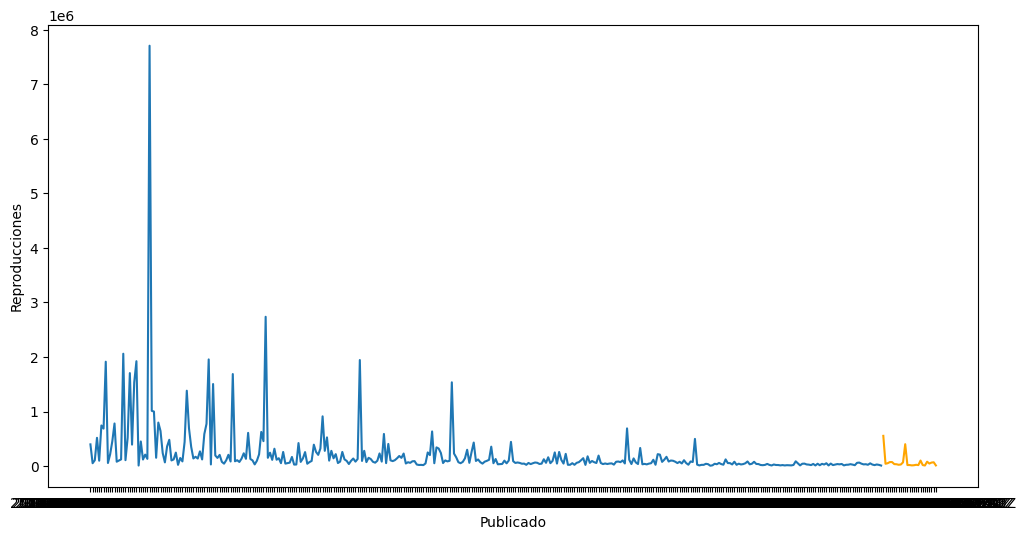

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt .figure(figsize=(12, 6))
sns.lineplot(data=historico_f1.sort_values(by='Publicado'), x='Publicado', y='Reproducciones')
sns.lineplot(data=historico_rocha.sort_values(by='Publicado'), x='Publicado', y='Reproducciones', color='orange')


In [ ]:
from datetime import datetime, timedelta

def get_topic_historical_data(query, years=5):
    all_video_data = []
    
    # Calculamos la fecha límite (RFC 3339 format)
    start_date = (datetime.now() - timedelta(days=years*365)).strftime('%Y-%m-%dT%H:%M:%SZ')
    print(f"Fecha de inicio: {start_date}")
    next_page_token = None
    
    # Hacemos varias peticiones para tener una muestra representativa (ej. 5 páginas = 250 videos)
    for _ in range(5): 
        print(start_date, " - Página ", _+1)
        #obtenemos los videos relacionados con el query y publicados después de la fecha límite
        search_res = youtube.search().list(
            q=query,
            part='snippet',
            type='video',
            publishedAfter=start_date,
            maxResults=50,
            order='viewCount', # Traemos los más relevantes/vistos
            pageToken=next_page_token
        ).execute()
        
        video_ids = [item['id']['videoId'] for item in search_res['items']]
        print(f"Videos obtenidos: {len(video_ids)}")
        # Obtenemos las estadísticas de esos videos
        stats_res = youtube.videos().list(
            id=','.join(video_ids),
            part='statistics,snippet'
        ).execute()
        
        for video in stats_res['items']:
            all_video_data.append({
                'fecha': datetime.strptime(video['snippet']['publishedAt'], '%Y-%m-%dT%H:%M:%SZ'),
                'vistas': int(video['statistics'].get('viewCount', 0))
            })
            
        next_page_token = search_res.get('nextPageToken')
        if not next_page_token:
            break

    # Procesamiento con Pandas
    df = pd.DataFrame(all_video_data)
    df['año_mes'] = df['fecha'].dt.to_period('M')
    
    # Agrupamos para ver el volumen de vistas por mes de publicación
    df_trend = df.groupby('año_mes')['vistas'].agg(['sum', 'count']).reset_index()
    df_trend.columns = ['año_mes', 'total_reproducciones', 'cantidad_videos']
    df_trend['año_mes'] = df_trend['año_mes'].astype(str)
    
    return df_trend

# Uso:
df_bricolaje = get_topic_historical_data("IA")
df_bricolaje.head(100)

Fecha de inicio: 2021-03-25T09:29:45Z
2021-03-25T09:29:45Z  - Página  1
Videos obtenidos: 50
2021-03-25T09:29:45Z  - Página  2
Videos obtenidos: 50
2021-03-25T09:29:45Z  - Página  3
Videos obtenidos: 50
2021-03-25T09:29:45Z  - Página  4
Videos obtenidos: 50
2021-03-25T09:29:45Z  - Página  5
Videos obtenidos: 50


,año_mes,total_reproducciones,cantidad_videos
0,2023-07,1571540,1
1,2023-11,752905,1
2,2024-01,648194,1
3,2024-02,564664,1
4,2024-04,802160,1
5,2024-05,803255,1
6,2024-06,30828882,2
7,2024-07,81200973,7
8,2024-08,5937247,3
9,2024-10,24734944,5


<Axes: xlabel='año_mes', ylabel='total_reproducciones'>

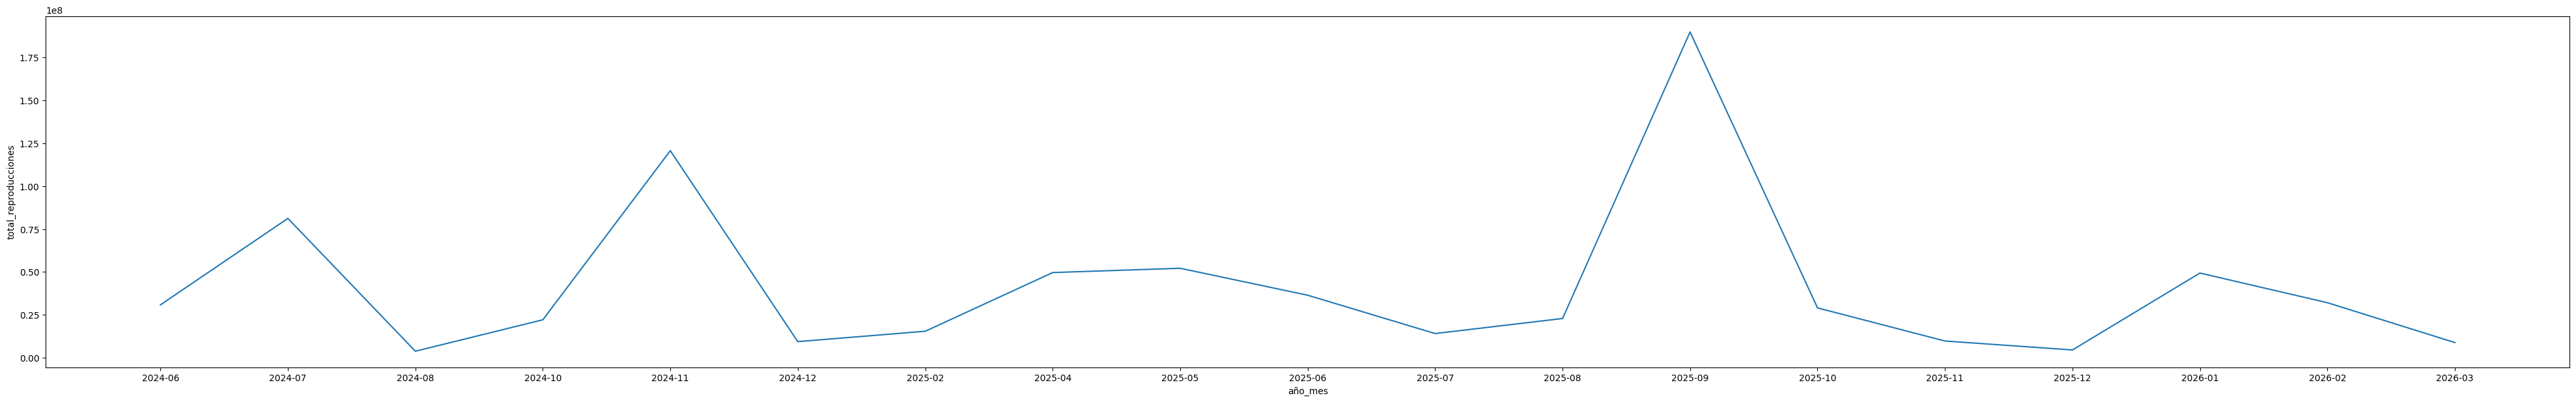

In [80]:
plt.figure(figsize=(50, 7))
sns.lineplot(data=df_bricolaje.sort_values(by='año_mes'), x='año_mes', y='total_reproducciones')